In [1]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f3e6754d52c92c3cf13e61f460f079f533e0aadcfcf84330f5cf7b7ab2b42796
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import qiskit_ibm_runtime
print(qiskit_ibm_runtime.__version__)
import qiskit
print(qiskit.__version__)
import qiskit_aer
print(qiskit_aer.__version__)

0.45.1
2.3.0
0.17.2


In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, SamplerV2
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.circuit.library import HGate

In [4]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="LFsogztwnQVatNMK70c2hV_PMd7h_2-5vYl8zvCBI24p", overwrite=True)

Step1: Transformation (Repetition of qubits): Encode the information $|ψ⟩$ by using entanglement.
|Ψ⟩ = α|0⟩ + β|1⟩

|Ψ⟩|00⟩ =>(entanglement) α|000⟩+β|111⟩

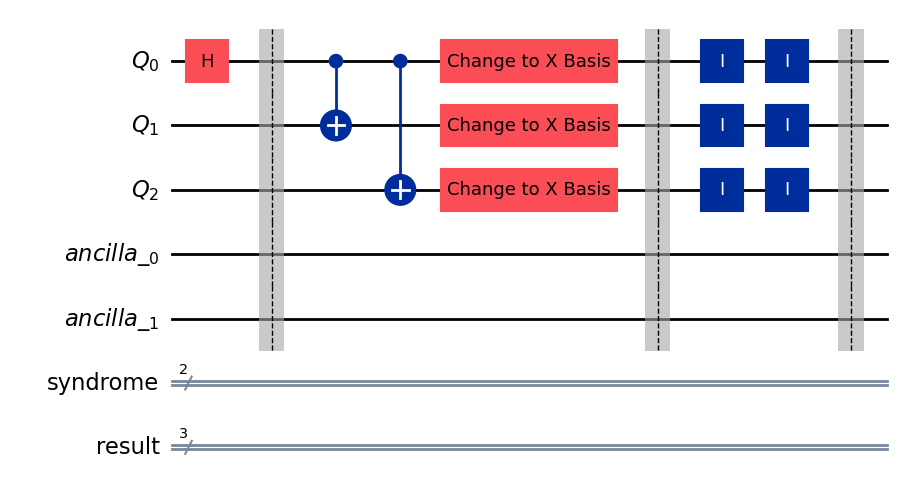

In [5]:
# 3 data qubits, 2 ancilla qubits, 2 syndrome bits

q_data = QuantumRegister(3, 'Q')
q_ancilla = QuantumRegister(2, 'ancilla_')
c_syn = ClassicalRegister(2, 'syndrome')
result_bit = ClassicalRegister(3, 'result')  # To measure the final state
qc = QuantumCircuit(q_data, q_ancilla, c_syn, result_bit)

# Encode: |ψ⟩|00> -> α|000⟩+β|111⟩
# We start with Q0 in α|0⟩ + β|1⟩ and spread it to Q1 and Q2

qc.h(q_data[0])
qc.barrier()

qc.cx(q_data[0], q_data[1])
qc.cx(q_data[0], q_data[2])
# qc.barrier()


# Create a Hadamard gate with a custom label
h_gate_x = HGate(label="Change to X Basis")
h_gate_z = HGate(label="Change to Z Basis")
for i in range(3):
    qc.append(h_gate_x, [q_data[i]])

qc.barrier()

# 1. Define the Error Block

# error_circ = QuantumCircuit(3, name="Error")
# error_circ.id(0)
# error_circ.id(1)
# error_circ.id(2)

# # 2. Convert to a gate
# error_gate = error_circ.to_gate()

# # 3. Add to your main circuit
# qc.append(error_gate, [0, 1, 2])   # Apply to qubits 0, 1 and 2
# qc.z(q_data[0])
qc.id(q_data[0:3])
qc.id(q_data[0:3])

qc.barrier()

qc.draw(output="mpl")

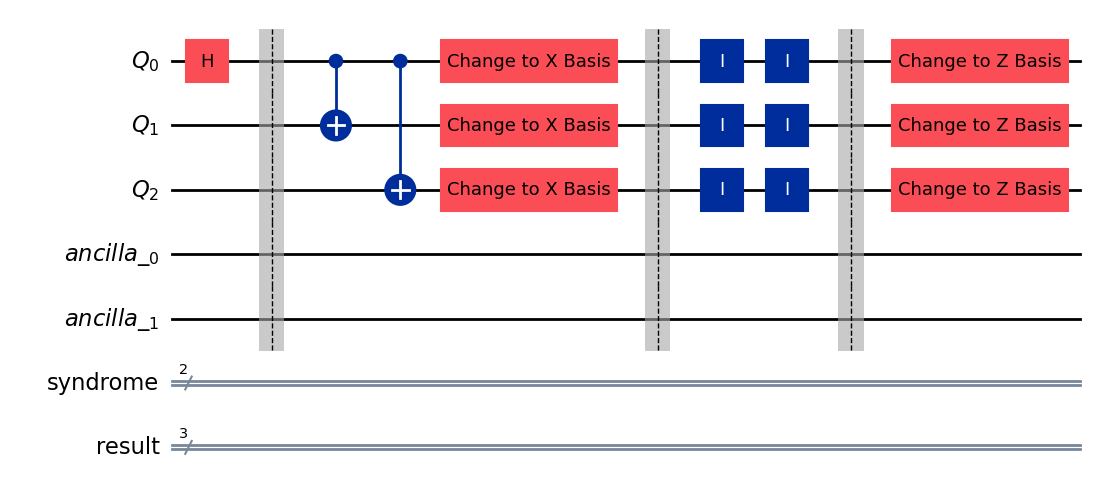

In [6]:
for i in range(3):
    qc.append(h_gate_z, [q_data[i]])    # Return to Z-basis (Phase-flip is now a Bit-flip)

qc.draw(output="mpl")

Simulate an Error: Manually inject a bit-flip (X gate) on one of the data qubits to test the circuit.

In [7]:
# Construct a 10% phase-flip error
p_error = 0.1
phase_flip = pauli_error([("Z", p_error), ("I", 1 - p_error)])

# Add error to a NoiseModel
# We'll trigger the error every time the simulator sees an 'id' gate
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(phase_flip, ['h','id'])
# noise_model.add_basis_gates(['Error'])


Step 2: Syndrome Extraction: Use the ancilla qubits to perform parity checks $(Z_{1}Z_{2})$ and $(Z_{2}Z_{3})$ without measuring the data qubits directly.

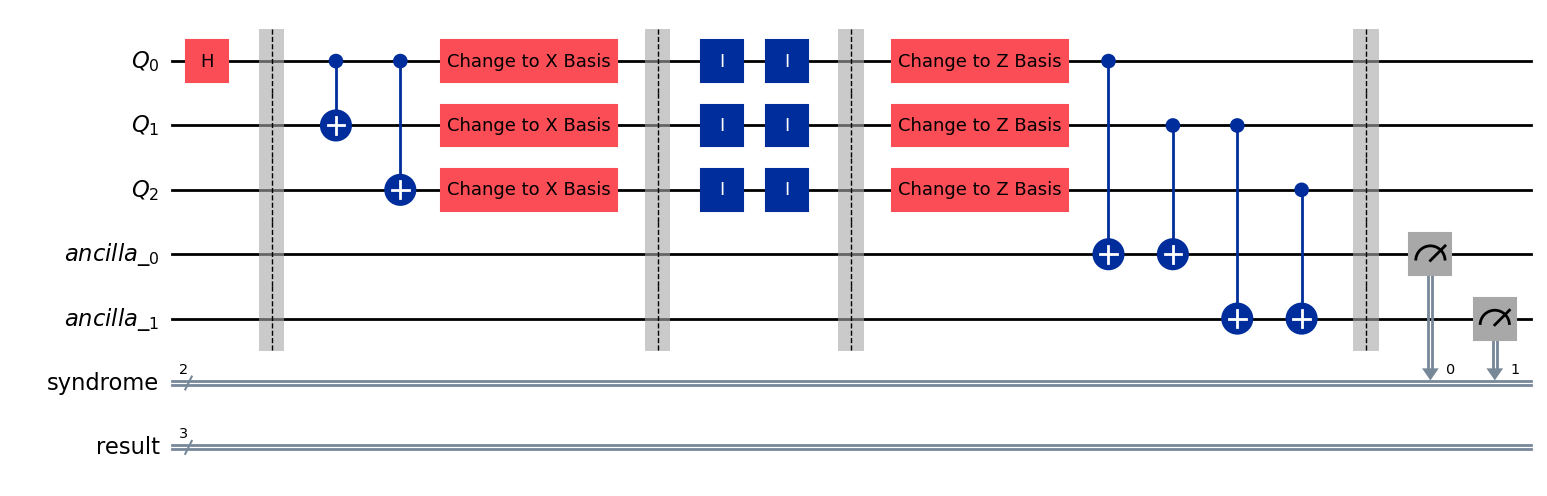

In [8]:
# Syndrome Extraction (Stabilizer Measurements)
# Check parity of Q0 and Q1

qc.cx(q_data[0], q_ancilla[0])
qc.cx(q_data[1], q_ancilla[0])

# Check parity of Q1 and Q2
qc.cx(q_data[1], q_ancilla[1])
qc.cx(q_data[2], q_ancilla[1])

qc.barrier()


# Measure the Syndrome (Measure ancillas to get the syndrome)
qc.measure(q_ancilla, c_syn)

qc.draw(output="mpl")

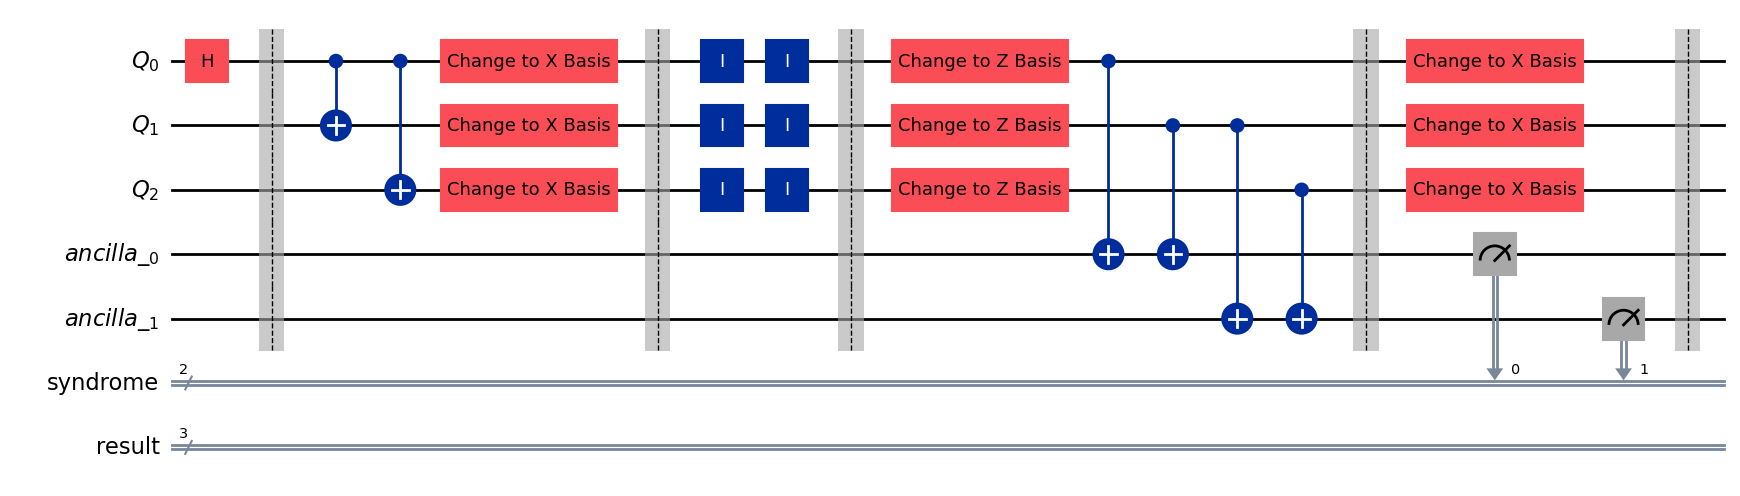

In [9]:
for i in range(3):
    qc.append(h_gate_x, [q_data[i]])
qc.barrier()

qc.draw(output="mpl")

Step 3: Correction: Apply conditional logic using the if_test instruction to flip the corrupted qubit based on the measured syndrome.

In [10]:
# Note: syndrome is read as (ancilla_1)(ancilla_0)
# If syndrome is '01' (binary 1), qubit Q0 (1st bit) is flipped (based on parity logic)
with qc.if_test((c_syn, 1)):
    qc.z(q_data[0])

# Additional cases for syndromes '10'(binary 2) (qubit Q2-3rd bit) and '11' (binary 3) (qubit Q1-Second bit)
with qc.if_test((c_syn, 2)):
    qc.z(q_data[2])

with qc.if_test((c_syn, 3)):
    qc.z(q_data[1])

qc.barrier()

for i in range(3):
    qc.append(h_gate_z, [q_data[i]])

#Final Measurement (Verify the logical state is back to |1>)
# We measure Q0; if correction worked, it should be 1 with 100% probability
qc.measure(q_data, result_bit)

# Run Simulation

sim = AerSimulator(noise_model = noise_model)
# sim = AerSimulator()
qc_transpiled = transpile(qc, sim)
job = sim.run(qc_transpiled, shots=1000)
counts = job.result().get_counts()

print("Measurement Counts (Format: Result Syndrome):", counts)

Measurement Counts (Format: Result Syndrome): {'000 00': 518, '111 00': 482}


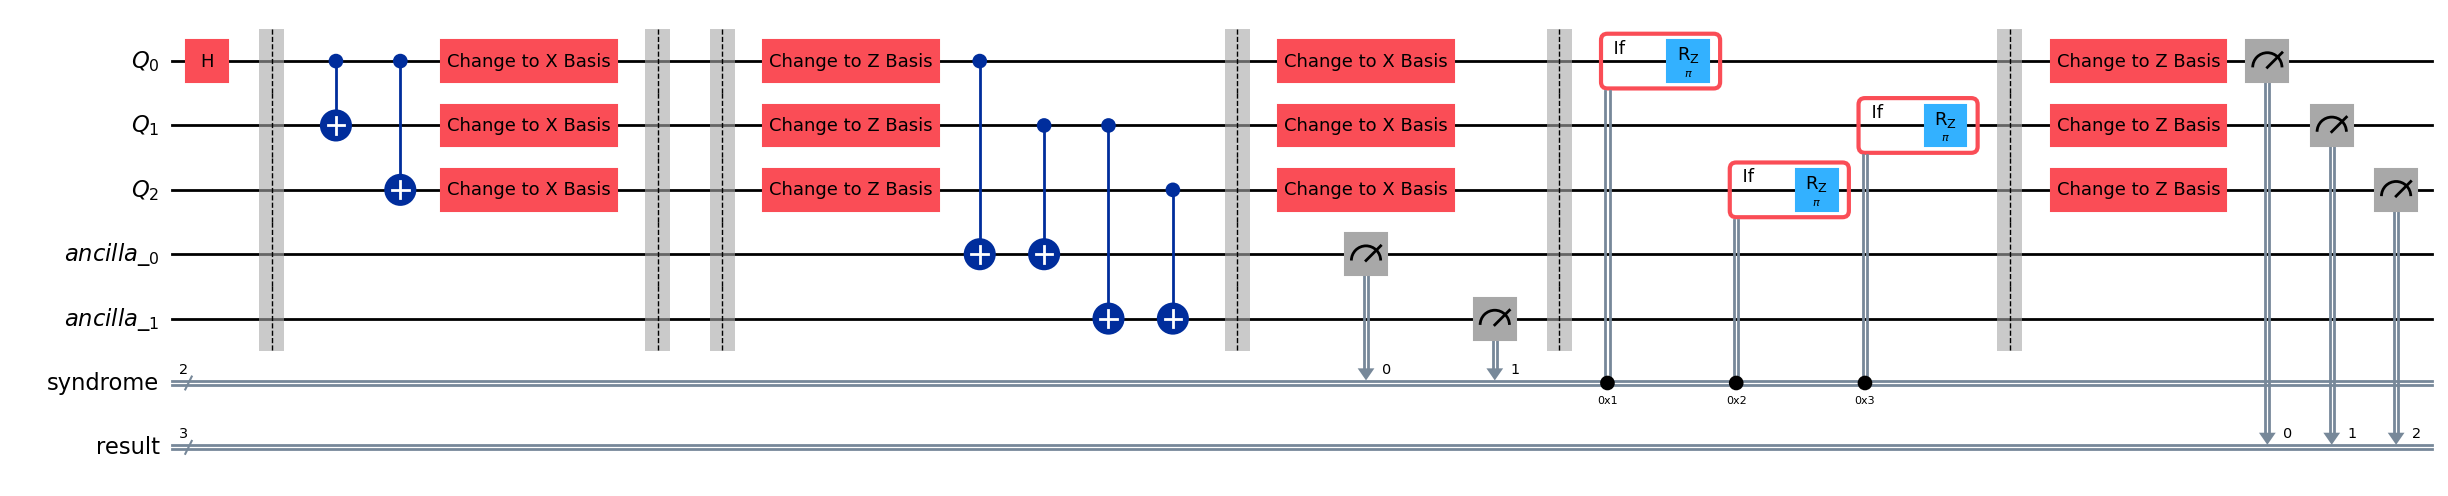

In [11]:
qc_transpiled.draw(output="mpl", fold=1)

In [12]:
job1 = sim.run(qc, shots=1000)
counts1 = job1.result().get_counts()

print("Measurement Counts (Format: Result Syndrome):", counts1)

Measurement Counts (Format: Result Syndrome): {'111 11': 71, '000 10': 72, '000 00': 288, '111 10': 73, '111 00': 259, '000 01': 80, '000 11': 83, '111 01': 74}


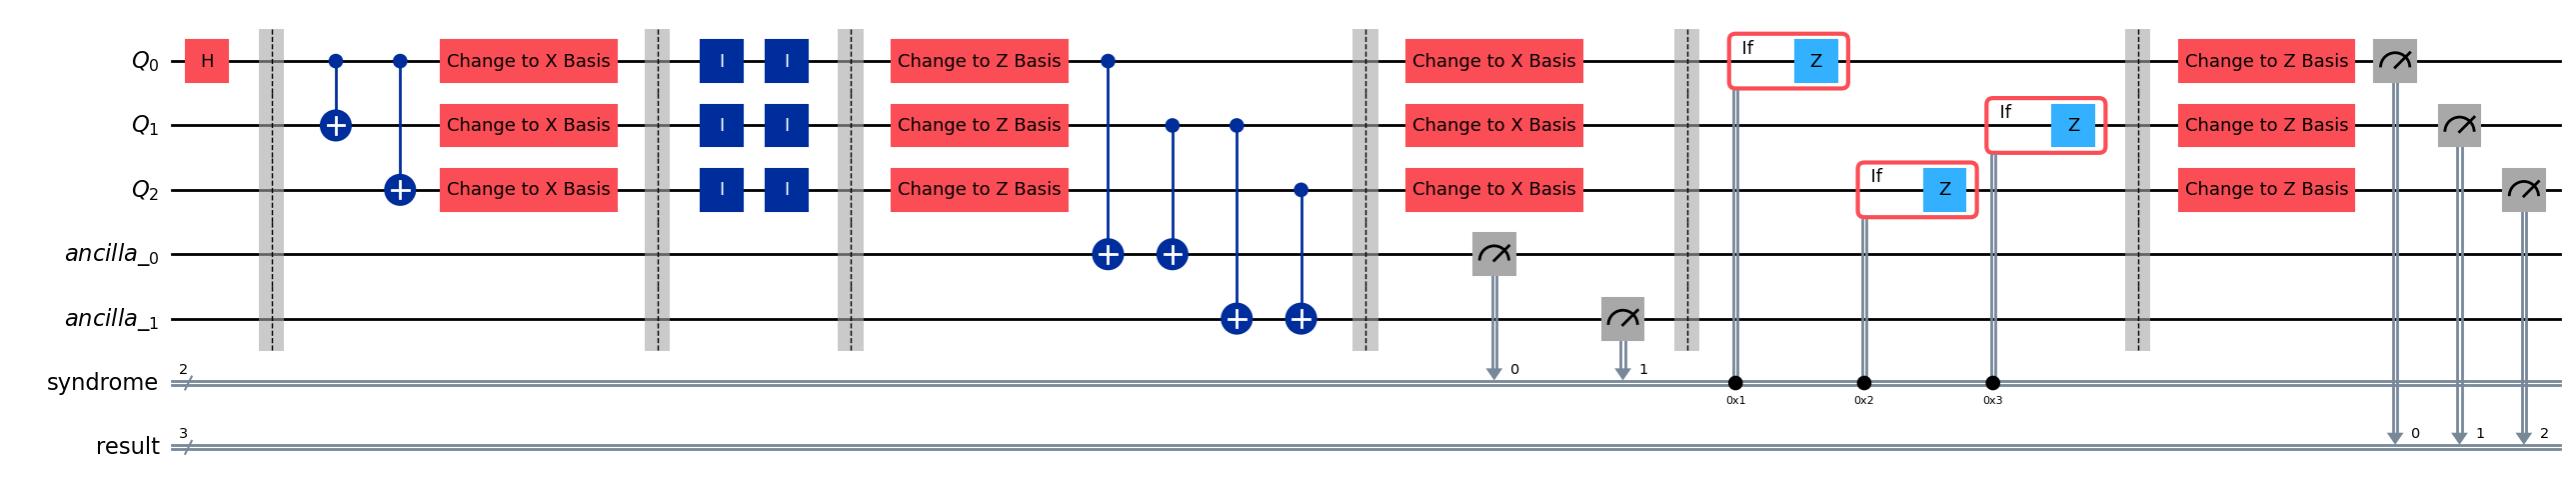

In [13]:
qc.draw(output="mpl", fold=1, measure_arrows=True)

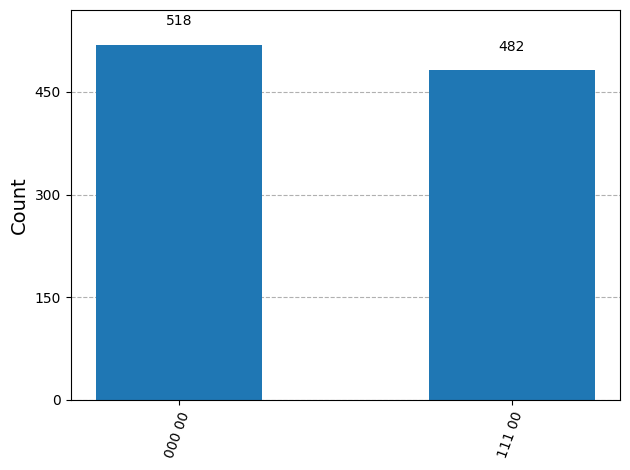

In [14]:
#histogram for results
from qiskit.visualization import plot_histogram
plot_histogram(counts)